## **INTRODUCTION**

The following dataset is from a 2014 survey that measures attitudes towards mental health and frequency of mental health disorders in the tech workplace. The objective of this project is to apply core data science skills such as data cleaning, wrangling, and exploratory data analysis (EDA). I will handle missing values, explore data types, generate summary statistics, and create meaningful visualizations to uncover trends and insights.I'll attempt to make inferences on how mental health affects work, what features may contribute to their condition, what features affect the workers' tendencies to get treatment, and what features contribute to making their work spaces more supportive to their condition. The dataset contains the following data:

Timestamp – Date and time of the response

Age– Respondent’s age

Gender – Respondent’s gender

Country – Country of residence

State – U.S. state or territory (if applicable)

Self-employed – Whether the respondent is self-employed

Family history – If there's a family history of mental illness

Treatment – Whether the respondent has sought mental health treatment

Work interfere – If mental health affects work performance

No. of employees – Company size

Remote work – Whether the respondent works remotely (50% or more)

Tech company – If the employer is a tech company

Benefits – If the employer offers mental health benefits

Care options – Awareness of available mental health care options at work

Wellness program – If mental health is included in wellness programs

Seek help – Availability of resources to seek mental health help

Anonymity – Whether anonymity is protected when using mental health resources

Leave – Ease of taking mental health leave

Mental health consequence – Fear of negative consequences from disclosing mental health issues

Physical health consequence – Fear of negative consequences from disclosing physical health issues

Coworkers – Willingness to talk to coworkers about mental health

Supervisor – Willingness to talk to supervisors about mental health

Mental health interview – Willingness to discuss mental health in job interviews

Physical health interview – Willingness to discuss physical health in job interviews

Mental vs physical – Perception of how equally mental and physical health are treated by the employer

Observed consequences – Whether the respondent has seen negative effects on coworkers with mental health issues

Comments – Any extra comments or notes

The tools used include Pandas for data manipulation, Matplotlib and Seaborn for visualization, all within a Jupyter Notebook.

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('data/survey.csv')

### Initial Inspection of dataset

In [3]:
print(df.head())

             Timestamp  Age  Gender         Country state self_employed  \
0  2014-08-27 11:29:31   37  Female   United States    IL           NaN   
1  2014-08-27 11:29:37   44       M   United States    IN           NaN   
2  2014-08-27 11:29:44   32    Male          Canada   NaN           NaN   
3  2014-08-27 11:29:46   31    Male  United Kingdom   NaN           NaN   
4  2014-08-27 11:30:22   31    Male   United States    TX           NaN   

  family_history treatment work_interfere    no_employees  ...  \
0             No       Yes          Often            6-25  ...   
1             No        No         Rarely  More than 1000  ...   
2             No        No         Rarely            6-25  ...   
3            Yes       Yes          Often          26-100  ...   
4             No        No          Never         100-500  ...   

                leave mental_health_consequence phys_health_consequence  \
0       Somewhat easy                        No                      No   
1 

From the head, I can see the type of data contained in each series. 

A few observations:
- The "self_employed" and "comments" column of the first 5 rows of the data set are all null. The comments may not have been recorded. It could be that the respondents thought that the field was unimportant or maybe the question asked when collecting data for that field was too vague.
- There are also inconsistencies in the "Gender" column (Representing 'Male' with 'Male' and 'M'and 'male', and 'Female' with 'f').
- Some 'state' values are also unavailable



In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

- The time stamp has a type of object instead of datetype.
- The comments column has too many NaN values and may need to be removed.
- Self employed, State and work_inference also have quite a large number of null values.

I believe that work_interference and self_employed are essential columns to this analysis when it comes to determining how mental health affects work and how work may affect mental health, so I won't drop them but I'll have to decide on ho to deal with the null values. 

In [5]:
print(df.shape)

(1259, 27)


In [6]:
df['Country'] = df['Country'].str.lower()
df['Country'] = df['Country'].str.strip()

countries = df['Country'].unique()

countries.sort()
countries

array(['australia', 'austria', 'bahamas, the', 'belgium',
       'bosnia and herzegovina', 'brazil', 'bulgaria', 'canada', 'china',
       'colombia', 'costa rica', 'croatia', 'czech republic', 'denmark',
       'finland', 'france', 'georgia', 'germany', 'greece', 'hungary',
       'india', 'ireland', 'israel', 'italy', 'japan', 'latvia', 'mexico',
       'moldova', 'netherlands', 'new zealand', 'nigeria', 'norway',
       'philippines', 'poland', 'portugal', 'romania', 'russia',
       'singapore', 'slovenia', 'south africa', 'spain', 'sweden',
       'switzerland', 'thailand', 'united kingdom', 'united states',
       'uruguay', 'zimbabwe'], dtype=object)

### Summary Statistics

In [7]:
print(df.describe())

                Age
count  1.259000e+03
mean   7.942815e+07
std    2.818299e+09
min   -1.726000e+03
25%    2.700000e+01
50%    3.100000e+01
75%    3.600000e+01
max    1.000000e+11


The mean value here shows that there is an invalid age value in the dataset.

In [8]:
print(df.describe(include='all'))

                  Timestamp           Age Gender        Country state  \
count                  1259  1.259000e+03   1259           1259   744   
unique                 1246           NaN     49             48    45   
top     2014-08-27 12:44:51           NaN   Male  united states    CA   
freq                      2           NaN    615            751   138   
mean                    NaN  7.942815e+07    NaN            NaN   NaN   
std                     NaN  2.818299e+09    NaN            NaN   NaN   
min                     NaN -1.726000e+03    NaN            NaN   NaN   
25%                     NaN  2.700000e+01    NaN            NaN   NaN   
50%                     NaN  3.100000e+01    NaN            NaN   NaN   
75%                     NaN  3.600000e+01    NaN            NaN   NaN   
max                     NaN  1.000000e+11    NaN            NaN   NaN   

       self_employed family_history treatment work_interfere no_employees  \
count           1241           1259      1259 

49 unique genders may indicate that there may be inconsistencies with how the genders are represented (given that this survey was taken in 2014). 

## **DATA CLEANING**

### Dropping Columns with Too Many Null Values
The first step I'll be taking to clean this data will be to drop the 'comments' column as it has too many null values. I'll also drop the 'state' column.

In [9]:
df = df.loc[:, df.isnull().mean() < 0.4]

In [10]:
print(df.columns)

Index(['Timestamp', 'Age', 'Gender', 'Country', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence'],
      dtype='object')


### Parsing Dates Correctly

Next, I'll change the type of the 'Timstamp' column from 'object' to 'datetime'.

In [11]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Timestamp                  1259 non-null   datetime64[ns]
 1   Age                        1259 non-null   int64         
 2   Gender                     1259 non-null   object        
 3   Country                    1259 non-null   object        
 4   self_employed              1241 non-null   object        
 5   family_history             1259 non-null   object        
 6   treatment                  1259 non-null   object        
 7   work_interfere             995 non-null    object        
 8   no_employees               1259 non-null   object        
 9   remote_work                1259 non-null   object        
 10  tech_company               1259 non-null   object        
 11  benefits                   1259 non-null   object        
 12  care_o

### Fixing Inconsistencies

In [13]:
genders = df['Gender'].unique()

genders.sort()
genders

array(['A little about you', 'Agender', 'All', 'Androgyne', 'Cis Female',
       'Cis Male', 'Cis Man', 'Enby', 'F', 'Femake', 'Female', 'Female ',
       'Female (cis)', 'Female (trans)', 'Genderqueer', 'Guy (-ish) ^_^',
       'M', 'Mail', 'Make', 'Mal', 'Male', 'Male ', 'Male (CIS)',
       'Male-ish', 'Malr', 'Man', 'Nah', 'Neuter', 'Trans woman',
       'Trans-female', 'Woman', 'cis male', 'cis-female/femme', 'f',
       'femail', 'female', 'fluid', 'm', 'maile', 'male',
       'male leaning androgynous', 'msle', 'non-binary',
       'ostensibly male, unsure what that really means', 'p', 'queer',
       'queer/she/they', 'something kinda male?', 'woman'], dtype=object)

In [14]:
df['Gender'] = df['Gender'].str.lower()
df['Gender'] = df['Gender'].str.strip()

genders = df['Gender'].unique()

genders.sort()
genders

array(['a little about you', 'agender', 'all', 'androgyne', 'cis female',
       'cis male', 'cis man', 'cis-female/femme', 'enby', 'f', 'femail',
       'femake', 'female', 'female (cis)', 'female (trans)', 'fluid',
       'genderqueer', 'guy (-ish) ^_^', 'm', 'mail', 'maile', 'make',
       'mal', 'male', 'male (cis)', 'male leaning androgynous',
       'male-ish', 'malr', 'man', 'msle', 'nah', 'neuter', 'non-binary',
       'ostensibly male, unsure what that really means', 'p', 'queer',
       'queer/she/they', 'something kinda male?', 'trans woman',
       'trans-female', 'woman'], dtype=object)

There are inconsistencies in the way respondents entered their genders and some entered phrases rather than genders. I'll use a simple function to group the genders in to 'male', 'female', 'trans-man', 'trans-woman', 'queer', and 'other' since there aren't too many unique entries.

In [15]:
def clean_gender_column(g):
    
    g = str(g).lower().strip() 

    if g in ['male', 'm', 'cis male', 'man', 'msle', 'mail', 'malr', 'mal', 'maile', 'make', 'male (cis)', 'male-ish', 'cis man']:
        return 'male'
    elif g in ['female', 'f', 'cis female', 'woman', 'femail', 'femake', 'female (cis)', 'cis-female/femme']:
        return 'female'
    else:
        return "other" 

df['Gender'] = df['Gender'].apply(clean_gender_column)


In [16]:
genders = df['Gender'].unique()

genders.sort()
genders

array(['female', 'male', 'other'], dtype=object)

In [17]:
df['Gender'].nunique()

3

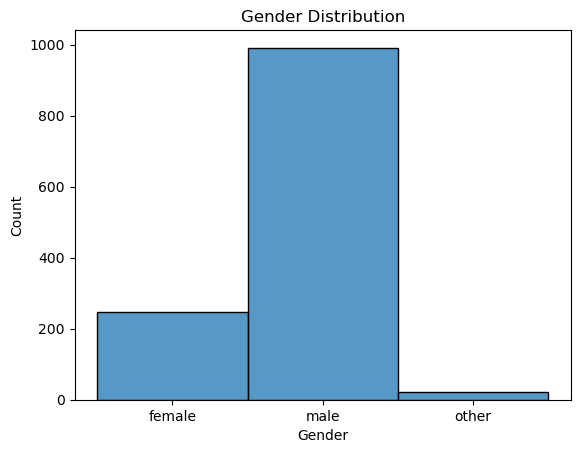

In [18]:
sns.histplot(df['Gender'])
plt.title('Gender Distribution');

In [19]:
df['Country'].nunique()

48

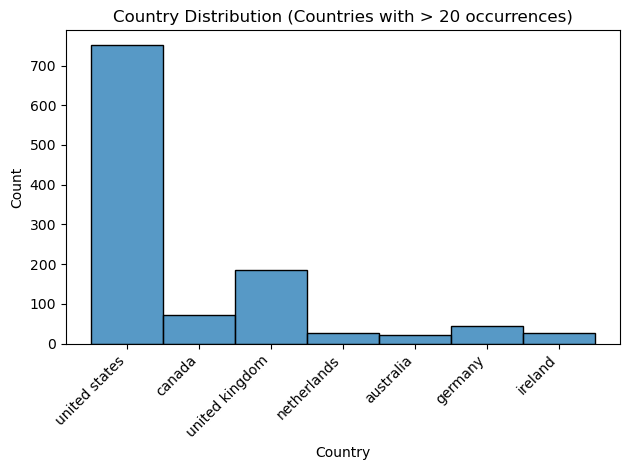

In [20]:
country_counts = df['Country'].value_counts()
countries_to_plot = country_counts[country_counts > 20].index
filtered_df = df[df['Country'].isin(countries_to_plot)]

sns.histplot(data=filtered_df, x='Country')
plt.title('Country Distribution (Countries with > 20 occurrences)')
plt.xticks(rotation=45, ha='right')  # Rotate country labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [21]:
ages = df['Age'].unique()

ages.sort()
ages

array([      -1726,         -29,          -1,           5,           8,
                11,          18,          19,          20,          21,
                22,          23,          24,          25,          26,
                27,          28,          29,          30,          31,
                32,          33,          34,          35,          36,
                37,          38,          39,          40,          41,
                42,          43,          44,          45,          46,
                47,          48,          49,          50,          51,
                53,          54,          55,          56,          57,
                58,          60,          61,          62,          65,
                72,         329, 99999999999], dtype=int64)

Given that this column is supposed to contain the ages of a sample of tech workers. A number of the ages here cannot be considered as valid entries. Some are negative numbers, while some are either too small to be the age of a tech worker, or too large to be a valid age.

In [22]:
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

ages = df['Age'].unique()

ages.sort()
ages

array([18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30.,
       31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43.,
       44., 45., 46., 47., 48., 49., 50., 51., 53., 54., 55., 56., 57.,
       58., 60., 61., 62., 65., 72., nan])

Since I cannot guess what the NaN values may be for work_interfere and self_employed, I'll be imputing the most common answer (the mode)

In [23]:
df['work_interfere'].fillna(df['work_interfere'].mode()[0], inplace=True)

work_interference = df['work_interfere'].unique()

work_interference.sort()
work_interference



C:\Users\user\AppData\Local\Temp\ipykernel_18240\1374605013.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['work_interfere'].fillna(df['work_interfere'].mode()[0], inplace=True)


array(['Never', 'Often', 'Rarely', 'Sometimes'], dtype=object)

In [24]:
df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True) 

self_employment = df['self_employed'].unique()

self_employment.sort()
self_employment

C:\Users\user\AppData\Local\Temp\ipykernel_18240\2728938734.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)


array(['No', 'Yes'], dtype=object)

Since Majority of the respondents have "united states" as their country, I decided to drop the data from other countries to reduce the impact of countries that might skew the data due to low sample size. I'll do the same for rare ages and genders too.

In [25]:
df = df[df["Country"] == "united states"]

In [26]:
age_counts = df["Age"].value_counts()
df = df[(df["Age"].isin(age_counts[age_counts >= 10].index))]

In [27]:
gender_counts = df["Gender"].value_counts()
df = df[(df["Gender"].isin(gender_counts[gender_counts >= 50].index))]

In [28]:
df.dropna()

,Timestamp,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,2014-08-27 11:29:31,37.0,female,united states,No,No,Yes,Often,6-25,No,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
4,2014-08-27 11:30:22,31.0,male,united states,No,No,No,Never,100-500,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No
5,2014-08-27 11:31:22,33.0,male,united states,No,Yes,No,Sometimes,6-25,No,...,Don't know,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No
6,2014-08-27 11:31:50,35.0,female,united states,No,Yes,Yes,Sometimes,1-5,Yes,...,No,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No
8,2014-08-27 11:32:39,42.0,female,united states,No,Yes,Yes,Sometimes,100-500,No,...,No,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253,2015-08-25 19:59:38,36.0,male,united states,No,Yes,No,Rarely,More than 1000,No,...,Don't know,Somewhat easy,Maybe,Maybe,Some of them,Some of them,No,No,Don't know,No
1255,2015-09-26 01:07:35,32.0,male,united states,No,Yes,Yes,Often,26-100,Yes,...,Yes,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No
1256,2015-11-07 12:36:58,34.0,male,united states,No,Yes,Yes,Sometimes,More than 1000,No,...,Don't know,Somewhat difficult,Yes,Yes,No,No,No,No,No,No
1257,2015-11-30 21:25:06,46.0,female,united states,No,No,No,Sometimes,100-500,Yes,...,Don't know,Don't know,Yes,No,No,No,No,No,No,No


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 664 entries, 0 to 1258
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Timestamp                  664 non-null    datetime64[ns]
 1   Age                        664 non-null    float64       
 2   Gender                     664 non-null    object        
 3   Country                    664 non-null    object        
 4   self_employed              664 non-null    object        
 5   family_history             664 non-null    object        
 6   treatment                  664 non-null    object        
 7   work_interfere             664 non-null    object        
 8   no_employees               664 non-null    object        
 9   remote_work                664 non-null    object        
 10  tech_company               664 non-null    object        
 11  benefits                   664 non-null    object        
 12  care_options

## **VISUALISATIONS**

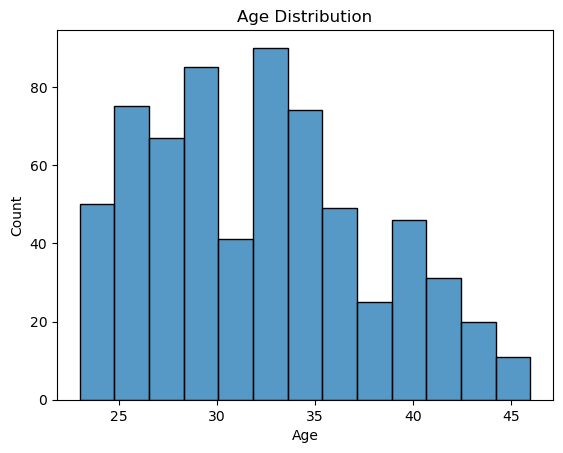

In [30]:
sns.histplot(df['Age'])
plt.title('Age Distribution');

### Factors that Affect the Likelihood of getting treatment

Text(0.5, 1.0, 'Gender vs. Tendency to Seek Treatment')

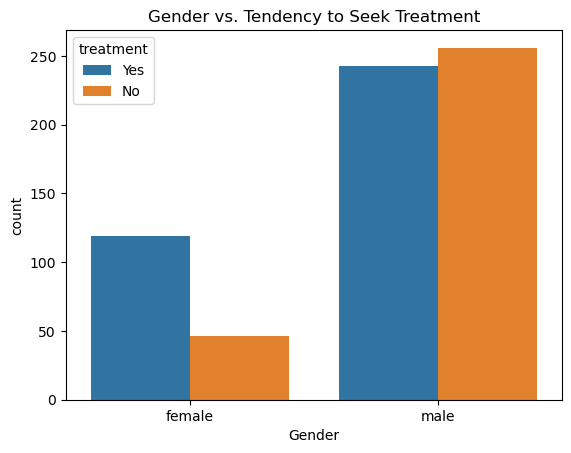

In [31]:
sns.countplot(data=df, x='Gender', hue='treatment')
plt.title('Gender vs. Tendency to Seek Treatment')

Text(0.5, 1.0, 'Effect of Family History on Treatment Seeking')

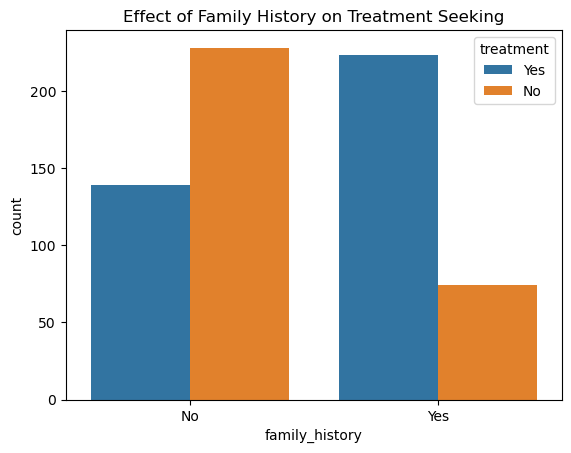

In [32]:
sns.countplot(data=df, x='family_history', hue='treatment')
plt.title('Effect of Family History on Treatment Seeking')

Text(0.5, 1.0, 'Coworker Support vs. Willingness to Seek Help')

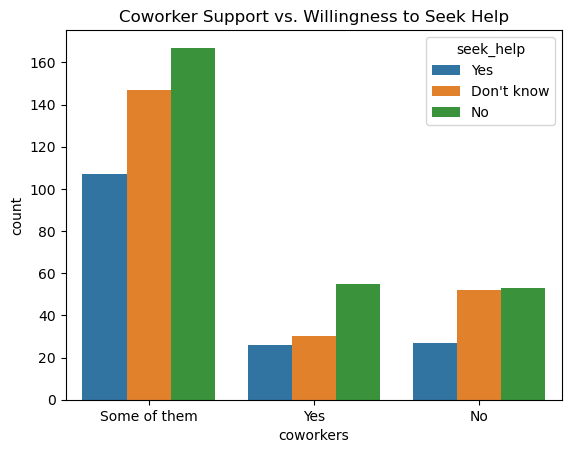

In [33]:
sns.countplot(data=df, x='coworkers', hue='seek_help')
plt.title('Coworker Support vs. Willingness to Seek Help')

In [34]:
df.groupby('coworkers')['seek_help'].value_counts(normalize=True) * 100

coworkers     seek_help 
No            No            40.151515
              Don't know    39.393939
              Yes           20.454545
Some of them  No            39.667458
              Don't know    34.916865
              Yes           25.415677
Yes           No            49.549550
              Don't know    27.027027
              Yes           23.423423
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Remote Work vs Treatment')

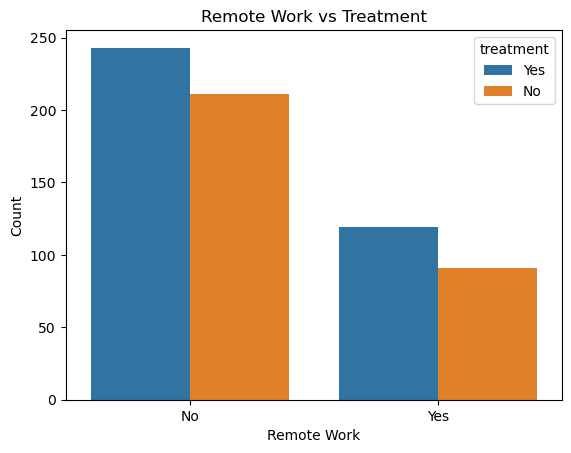

In [35]:
sns.countplot(data=df, x='remote_work', hue='treatment')
plt.xlabel('Remote Work')
plt.ylabel('Count')
plt.title('Remote Work vs Treatment')

In [36]:
df.groupby('remote_work')['treatment'].value_counts(normalize=True) * 100

remote_work  treatment
No           Yes          53.524229
             No           46.475771
Yes          Yes          56.666667
             No           43.333333
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Availability of Help vs. Treatment Seeking')

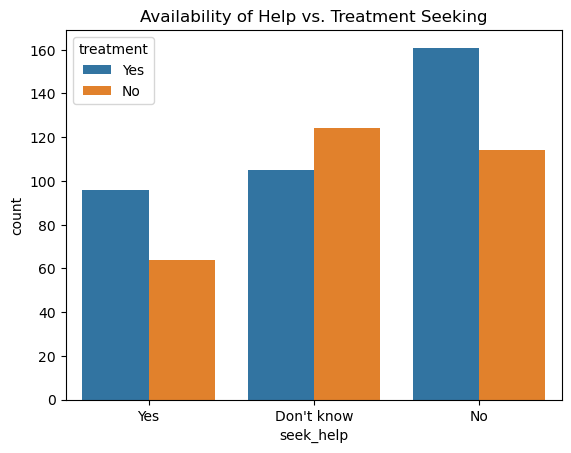

In [37]:
sns.countplot(data=df, x='seek_help', hue='treatment')
plt.title('Availability of Help vs. Treatment Seeking')

In [38]:
df.groupby('seek_help')['treatment'].value_counts(normalize=True) * 100

seek_help   treatment
Don't know  No           54.148472
            Yes          45.851528
No          Yes          58.545455
            No           41.454545
Yes         Yes          60.000000
            No           40.000000
Name: proportion, dtype: float64

- Gender and family history show some variation in treatment-seeking behavior.

- Supportive coworkers or supervisors does not have much impact on a worker seeking help

- People working remotely were just slightly more likely to get treatment, possibly due to flexibility.

### What Makes Workplaces more Supportive 

Text(0.5, 1.0, 'Coworker Support vs. Getting Treatment')

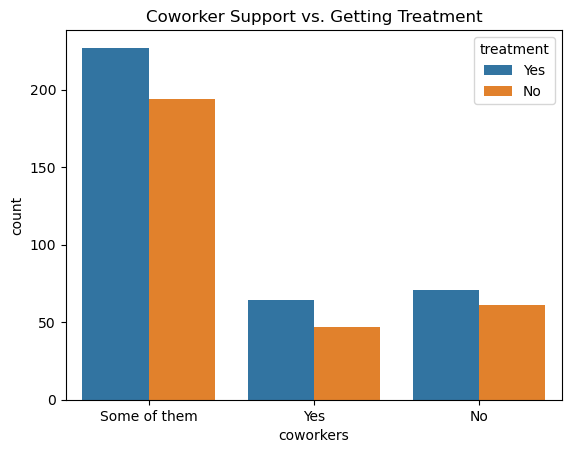

In [39]:
sns.countplot(data=df, x='coworkers', hue='treatment')

plt.title('Coworker Support vs. Getting Treatment')

Text(0.5, 1.0, 'Company Size vs Mental Health Benefits')

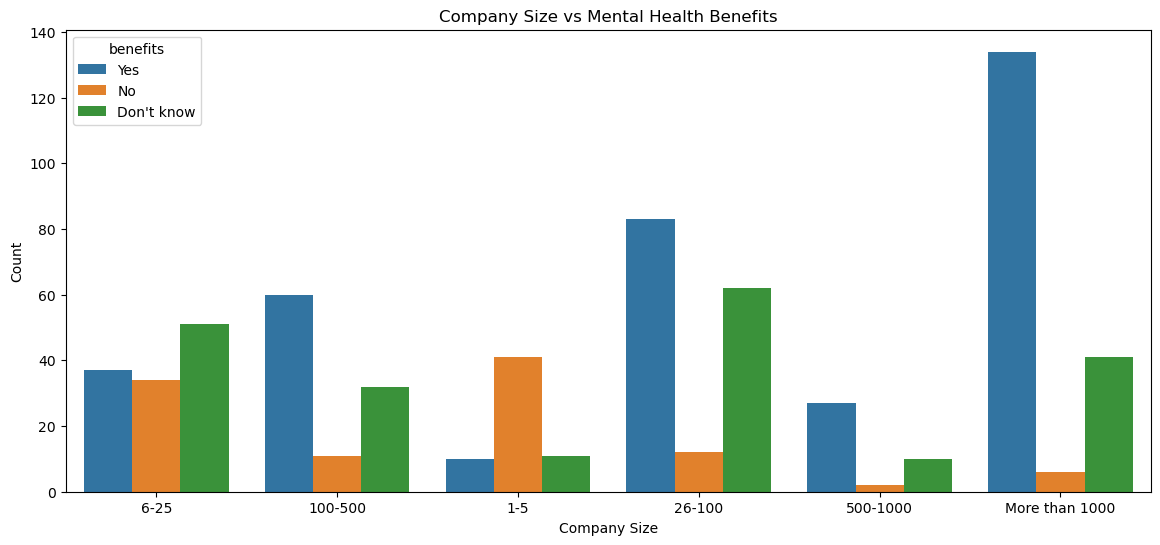

In [40]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='no_employees', hue='benefits')
plt.xlabel('Company Size')
plt.ylabel('Count')
plt.title('Company Size vs Mental Health Benefits')

Text(0.5, 1.0, 'Company Size vs Getting Treatment')

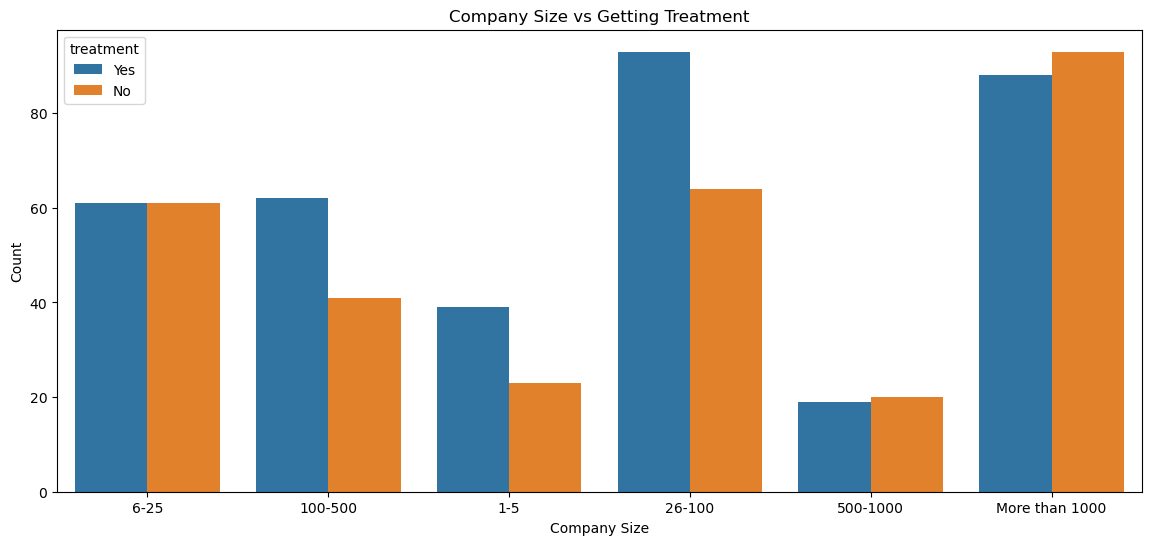

In [41]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='no_employees', hue='treatment')
plt.xlabel('Company Size')
plt.ylabel('Count')
plt.title('Company Size vs Getting Treatment')

Text(0.5, 1.0, 'Work Interference vs. Wellness Program Availability')

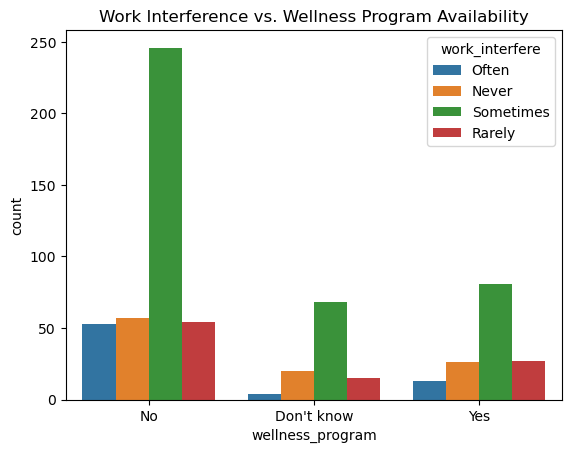

In [42]:
sns.countplot(data=df, x='wellness_program', hue='work_interfere')
plt.title('Work Interference vs. Wellness Program Availability')

- Larger companies offer more mental health benefits yet the people working in larger companies seem to be less likely to get treatment
- Companies having wellness programs does not really improve the work interference which may indicate that the programs aren't effective or aren’t being used.

#### How Mental Health Affects Work

Text(0.5, 1.0, 'Work Interference vs. Availability of Mental Health Benefits')

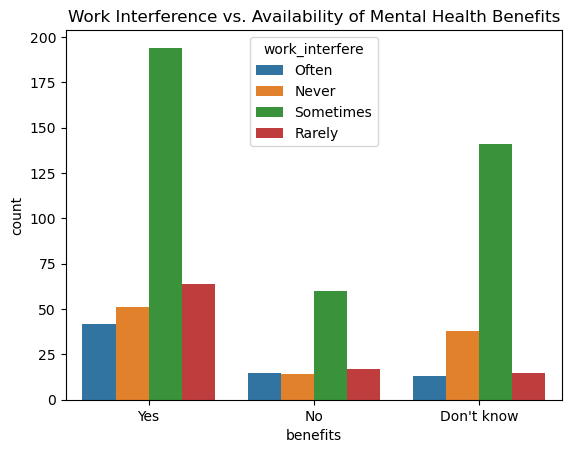

In [43]:
sns.countplot(data=df, x='benefits', hue='work_interfere')
plt.title('Work Interference vs. Availability of Mental Health Benefits')


Text(0.5, 1.0, 'Work Interference by Company Size')

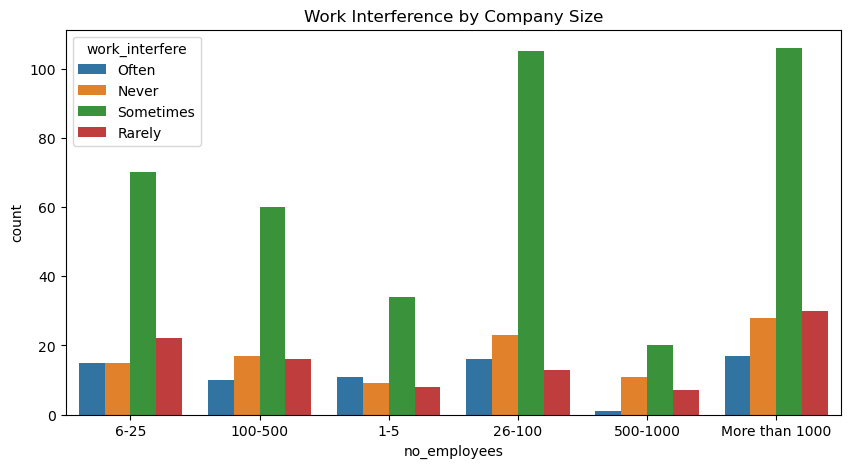

In [44]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='no_employees', hue='work_interfere')
plt.title('Work Interference by Company Size')

## **CONCLUSION**



This exploratory data analysis shows that mental health has a strong impact on employee productivity. Factors like family history, remote work status, organizational support, and company size influence both the risk of mental health issues and the likelihood of seeking treatment.

Supportive workplaces are often linked to better outcomes. However, some existing mental health programs appear ineffective. These insights point to areas where organizations can improve, helping to build healthier and more supportive work environments.